# Multivariate Linear Regression

### import basics



    X: (m, n)
    y: (m,)
    w: (n,)
    b: scalar


In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [29]:
data = np.loadtxt("housing_data.txt", dtype=float)

X = data[:, :-1]   
y = data[:, -1] 

### Feature Scaling

In [30]:
def feature_scale(X):
    # compute per-feature mean/std (axis=0)
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    # avoid division by zero
    std_repl = np.where(std == 0, 1.0, std)
    x_scaled = (X - mean) / std_repl
    return x_scaled, mean, std_repl


### Initialize Paramaters

In [31]:
def initialize_parameters(n_features):
    w = np.zeros(n_features)
    b = 0.0

    return w,b

### Vectorized Hypothesis

In [32]:
def hypothesis(X, w, b):
    # X: (m, n), w: (n,) -> result (m,)
    return X @ w + b

### Vectorized Cost Function (MSE)

In [33]:
def compute_cost(X, y, w, b):
    m = X.shape[0]   # number of examples (rows)
    h = hypothesis(X, w, b)
    assert h.shape == y.shape, f"shape mismatch h={h.shape} and y={y.shape}"
    errors = h - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return float(cost)

### Vectorized Gradients

In [34]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    h = hypothesis(X, w, b)
    assert h.shape == y.shape, f"h shape {h.shape} != y shape {y.shape}"
    errors = h - y
    dw = (1 / m) * (X.T @ errors)   # result shape (n,)
    db = (1 / m) * np.sum(errors)
    return dw, db

### Vectorized Gradient Descent Loop Code

In [35]:
def gradient_descent(X, y, w, b, learning_rate, iterations):
    cost_hist = []
    w_hist = []
    for i in range(iterations):
        dw, db = compute_gradient(X, y, w, b)
        w = w - (learning_rate * dw)
        b = b - (learning_rate * db)
        cost = compute_cost(X, y, w, b)
        cost_hist.append(cost)
        if i % 50 == 0:
            w_hist.append(w.copy())
            print(f"iter: {i} cost: {cost:.6f}")
        # stop early if cost explodes or becomes nan
        if np.isnan(cost) or np.isinf(cost):
            print(f"Stopping early at iter {i}: cost={cost}")
            break
    return w, b, cost_hist, w_hist

### Different Learning Rate

In [36]:
def test_LR(X,y, w, b, learning_rate, iter = 300):

    plt.figure(figsize=(10,6))

    for lr in learning_rate:
        n_feature = X.shape[1]
        w,b = initialize_parameters(n_feature)

        w_train, b_train, cost_hist, _ = gradient_descent(X,y, w, b, lr, iter)

        plt.plot(cost_hist, label= f"LR = {lr}")
    
        plt.xlabel("Iterations")
    
    plt.ylabel("Cost")
    plt.title("Cost vs Iterations for Different Learning Rates")
    plt.legend()
    plt.grid(True)
    plt.show()

### Plot Cost Curve

In [37]:
def plot_cost_curve(cost_hist):
    """
    Plots cost vs iterations for a single training run.
    """
    plt.figure(figsize=(8,5))
    plt.plot(cost_hist, label="Cost")
    plt.xlabel("Iterations")
    plt.ylabel("Cost (MSE)")
    plt.title("Gradient Descent Convergence")
    plt.grid(True)
    plt.legend()
    plt.show()


### plot weight convergence 


In [38]:
def plot_weight_convergence(w_hist):

    w_hist = np.array(w_hist)

    n_feature = w_hist.shape[1]

    plt.figure(figsize=(10,6))
    
    for j in range(n_feature):
        plt.plot(w_hist[:, j], label=f"w{j+1}")
    
    plt.xlabel("Snapshots")
    plt.ylabel("Weight Value")
    plt.title("Weight Convergence Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


### Final Learned Parameters


iter: 0 cost: 63378347668.630333
iter: 50 cost: 24074959040.835487
iter: 100 cost: 10064191346.553297
iter: 150 cost: 4955962926.013141
iter: 200 cost: 3053222806.396554
iter: 250 cost: 2325666663.231992
iter: 300 cost: 2036998482.489225
iter: 350 cost: 1916247561.711616
iter: 400 cost: 1862050602.885011
iter: 450 cost: 1835624491.356831
iter: 500 cost: 1821617808.157905
iter: 550 cost: 1813641535.332993
iter: 600 cost: 1808848905.755706
iter: 650 cost: 1805863446.102063
iter: 700 cost: 1803961387.347892
iter: 750 cost: 1802733223.091862
iter: 800 cost: 1801934021.099899
iter: 850 cost: 1801411657.207031
iter: 900 cost: 1801069386.220129
iter: 950 cost: 1800844805.350601
Trained params (scaled): [104851.52741716  -5380.89460372 -16171.13468249] 338833.2715134746
Parameters in original scale: [  136.41396499 -7187.95620298 -3745.40599871] 145721.37043504976


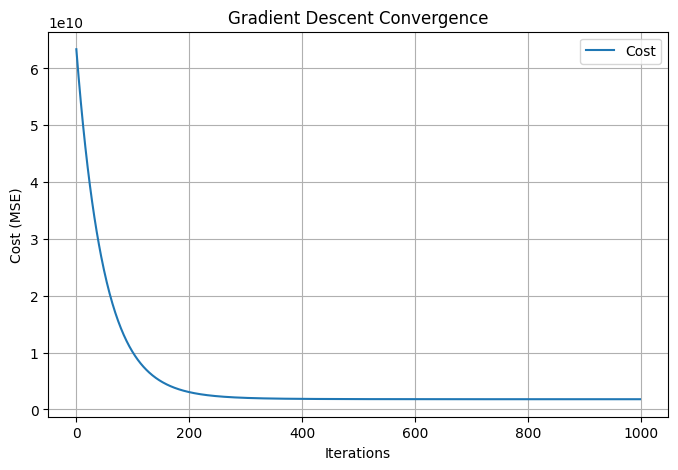

In [39]:
# prepare data and train
X_raw = X.copy()                  # from your data load cell
y_vec = y.copy()                  # ensure shape (m,)
X_scaled, mean, std = feature_scale(X_raw)
n_features = X_scaled.shape[1]
w_init, b_init = initialize_parameters(n_features)
# try a small learning rate if unsure
w_final, b_final, cost_hist, w_hist = gradient_descent(X_scaled, y_vec, w_init, b_init, learning_rate=0.01, iterations=1000)
print("Trained params (scaled):", w_final, b_final)
# unscale to original units (per-feature)
def unscale_parameters(w_scaled, b_scaled, mean, std):
    w_original = w_scaled / std
    b_original = b_scaled - np.sum((w_scaled * mean) / std)
    return w_original, b_original
w_orig, b_orig = unscale_parameters(w_final, b_final, mean, std)
print("Parameters in original scale:", w_orig, b_orig)
plot_cost_curve(cost_hist)

### Making predictions on new data

In [40]:
def predict(X_new, w, b, mean, std):
    """
    Predicts on new data using trained parameters.
    
    X_new: (n,) or (m, n)
    """
    X_new = np.array(X_new, dtype=float)
    
    # reshape if 1 example
    if X_new.ndim == 1:
        X_new = X_new.reshape(1, -1)
    
    # scale using training mean/std
    X_new_scaled = (X_new - mean) / std
    
    # vectorized prediction
    return X_new_scaled @ w + b


### Pulling everything together

data shape: X=(50, 3), y=(50,)
iter: 0 cost: 63378347668.630333
iter: 50 cost: 24074959040.835487
iter: 100 cost: 10064191346.553297
iter: 150 cost: 4955962926.013141
iter: 200 cost: 3053222806.396554
iter: 250 cost: 2325666663.231992
iter: 300 cost: 2036998482.489225
iter: 350 cost: 1916247561.711616
iter: 400 cost: 1862050602.885011
iter: 450 cost: 1835624491.356831
iter: 500 cost: 1821617808.157905
iter: 550 cost: 1813641535.332993
iter: 600 cost: 1808848905.755706
iter: 650 cost: 1805863446.102063
iter: 700 cost: 1803961387.347892
iter: 750 cost: 1802733223.091862
iter: 800 cost: 1801934021.099899
iter: 850 cost: 1801411657.207031
iter: 900 cost: 1801069386.220129
iter: 950 cost: 1800844805.350601
Trained (scaled) w: [104851.52741716  -5380.89460372 -16171.13468249]
Trained (scaled) b: 338833.2715134746
Parameters in original scale (w, b):
[  136.41396499 -7187.95620298 -3745.40599871] 145721.37043504976


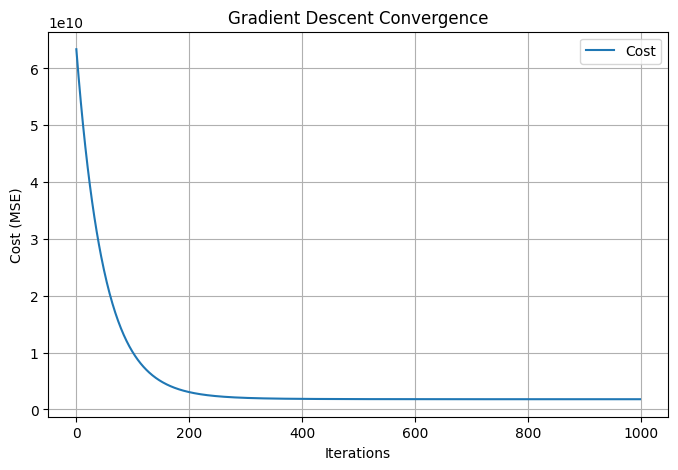

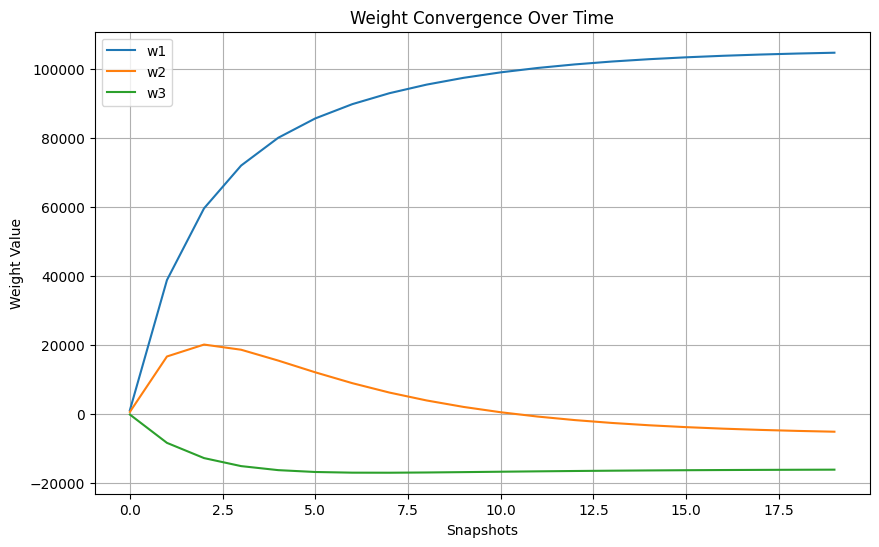


first 5 true vs predicted:
true=399900.000 pred=354991.394
true=329900.000 pred=267511.726
true=369000.000 pred=384133.710
true=232000.000 pred=268326.542
true=539900.000 pred=451303.321

Normal equation theta (bias first): [ 1.46693043e+05  1.37485016e+02 -8.28315008e+03 -3.72125029e+03]


In [41]:
# 1) load data if not already loaded
try:
    X_raw, y = X.copy(), y.copy()
except NameError:
    data = np.loadtxt("housing_data.txt", dtype=float)
    X_raw = data[:, :-1]
    y = data[:, -1]

# ensure y is shape (m,)
y = y.ravel()
m, n = X_raw.shape
print(f"data shape: X={X_raw.shape}, y={y.shape}")

# 2) feature scale (uses your feature_scale function)
X_scaled, mean, std = feature_scale(X_raw)

# 3) init params and train (uses your initialize_parameters & gradient_descent)
w_init, b_init = initialize_parameters(n)
learning_rate = 0.01
iterations = 1000
w_final, b_final, cost_hist, w_hist = gradient_descent(X_scaled, y, w_init, b_init, learning_rate, iterations)

# 4) show results (scaled-space)
print("Trained (scaled) w:", w_final)
print("Trained (scaled) b:", b_final)

# 5) unscale parameters to original units
def unscale_parameters(w_scaled, b_scaled, mean, std):
    w_original = w_scaled / std
    b_original = b_scaled - np.sum((w_scaled * mean) / std)
    return w_original, b_original

w_orig, b_orig = unscale_parameters(w_final, b_final, mean, std)
print("Parameters in original scale (w, b):")
print(w_orig, b_orig)

# 6) plot cost and weight convergence (uses your plotting functions)
plot_cost_curve(cost_hist)
if len(w_hist) > 0:
    plot_weight_convergence(w_hist)

# 7) quick predictions vs actual on first 5 examples (uses your predict function)
X_test = X_raw[:5]
y_test = y[:5]
y_pred = predict(X_test, w_final, b_final, mean, std).ravel()   # returns scaled-space predictions if predict uses scaled w/b
# If predict assumes w/b are in scaled-space (we trained on scaled X), this is correct.
print("\nfirst 5 true vs predicted:")
for true, pred in zip(y_test, y_pred):
    print(f"true={true:.3f} pred={pred:.3f}")

# 8) Normal equation on original X to compare (no scaling needed)
X_bias = np.hstack([np.ones((m,1)), X_raw])
theta_norm = np.linalg.pinv(X_bias.T @ X_bias) @ (X_bias.T @ y)
print("\nNormal equation theta (bias first):", theta_norm)

# ...existing code...

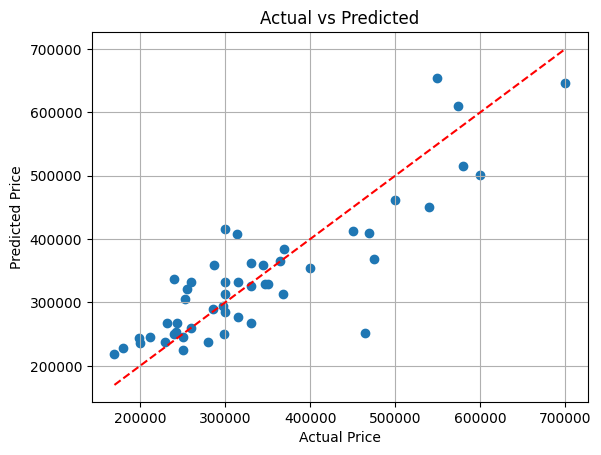

In [42]:
y_pred = X_scaled @ w_final + b_final

plt.scatter(y, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect line
plt.grid(True)
plt.show()


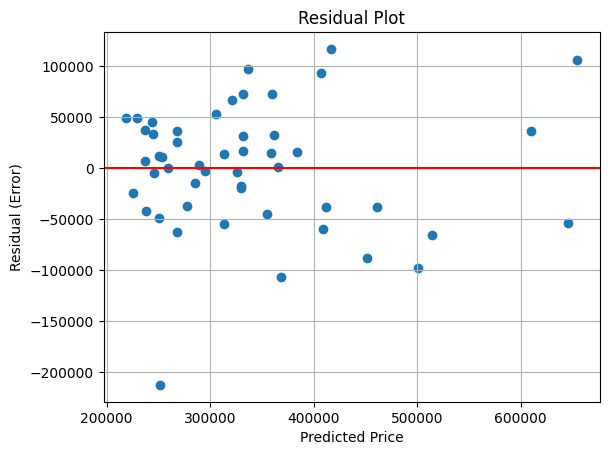

In [43]:
errors = y_pred - y

plt.scatter(y_pred, errors)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Error)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


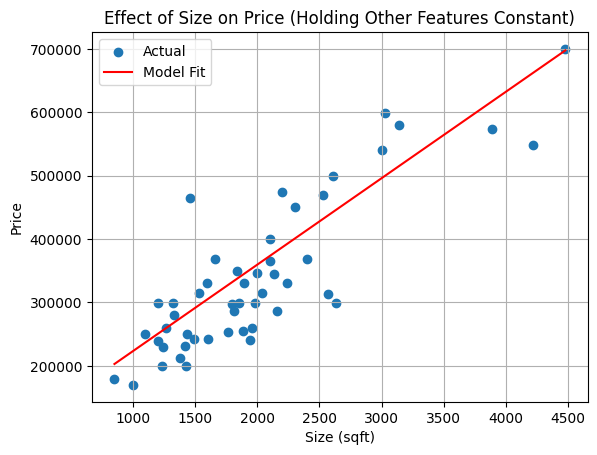

In [44]:
sizes = np.linspace(X[:,0].min(), X[:,0].max(), 100)

bedrooms = 3
age = 10

X_new = np.column_stack([sizes, 
                         np.full_like(sizes, bedrooms),
                         np.full_like(sizes, age)])

X_new_scaled = (X_new - mean) / std
y_size_curve = X_new_scaled @ w_final + b_final

plt.scatter(X[:,0], y, label="Actual")
plt.plot(sizes, y_size_curve, color='red', label="Model Fit")
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.title("Effect of Size on Price (Holding Other Features Constant)")
plt.legend()
plt.grid(True)
plt.show()


# Normal Equation 

In [45]:
# Design matrix with bias term for Normal Equation
# Using scaled features for fair comparison with GD
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]  # shape (m, n+1)

print("X_b shape:", X_b.shape)  # (m, n+1)


X_b shape: (50, 4)


In [46]:
def normal_equation(X_b, y, use_pinv=True):
    """
    Solves for theta using the normal equation.
    
    X_b: (m, n+1) -> with bias column
    y:   (m,)
    
    returns theta: (n+1,)
    """
    if use_pinv:
        theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
    else:
        theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    
    return theta


In [47]:
theta_ne = normal_equation(X_b, y, use_pinv=True)
print("theta_ne shape:", theta_ne.shape)
print("theta_ne:", theta_ne)


theta_ne shape: (4,)
theta_ne: [338847.9        105674.7664893   -6200.75530579 -16066.84020798]


In [48]:
b_ne = theta_ne[0]
w_ne = theta_ne[1:]

print("Normal Equation parameters:")
print("b_ne:", b_ne)
print("w_ne:", w_ne)


Normal Equation parameters:
b_ne: 338847.89999999997
w_ne: [105674.7664893   -6200.75530579 -16066.84020798]


In [49]:
# Predictions from GD model
y_pred_gd = X_scaled @ w_final + b_final

# Predictions from Normal Equation
y_pred_ne = X_scaled @ w_ne + b_ne

# RMSE comparison
rmse_gd = np.sqrt(mean_squared_error(y, y_pred_gd))
rmse_ne = np.sqrt(mean_squared_error(y, y_pred_ne))

print("RMSE (Gradient Descent):", rmse_gd)
print("RMSE (Normal Equation):", rmse_ne)


RMSE (Gradient Descent): 60011.66078069103
RMSE (Normal Equation): 60006.91148291499
